In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [4]:
# -------------------------------
# 1. Define dataset path
# -------------------------------
data_dir = r"C:\Users\avikr\OneDrive\Desktop\cv project"  # change this to your dataset folder path
# or
# data_dir = "C:\\Users\\avikr\\OneDrive\\Desktop\\cv project"

In [5]:
# -------------------------------
# 2. Create training and validation datasets
# -------------------------------
# We'll use 70% train, 20% validation, 10% test

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,       # 30% for val + test
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)


Found 999 files belonging to 1 classes.
Using 700 files for training.
Found 999 files belonging to 1 classes.
Using 299 files for validation.


In [6]:
# -------------------------------
# 3. Split val_test_ds into validation (20%) and test (10%)
# -------------------------------
val_size = 0.67  # 20% out of the 30% for validation
val_ds = val_test_ds.take(int(len(val_test_ds) * val_size))
test_ds = val_test_ds.skip(int(len(val_test_ds) * val_size))


In [7]:

# -------------------------------
# 4. Improve performance with caching and prefetching
# -------------------------------
# AUTOTUNE = tf.data.AUTOTUNE

# train_ds = train_ds.cache().shuffle(500).prefetch(buffer_size=AUTOTUNE)
# val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
# test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [8]:
# -------------------------------
# 5. Check class names and dataset info
# -------------------------------
class_names = train_ds.class_names  # Save before prefetching

print("Class names:", class_names)
print("Number of training batches:", len(train_ds))
print("Number of validation batches:", len(val_ds))
print("Number of test batches:", len(test_ds))


Class names: ['fire_dataset']
Number of training batches: 22
Number of validation batches: 6
Number of test batches: 4


c:\Users\avikr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


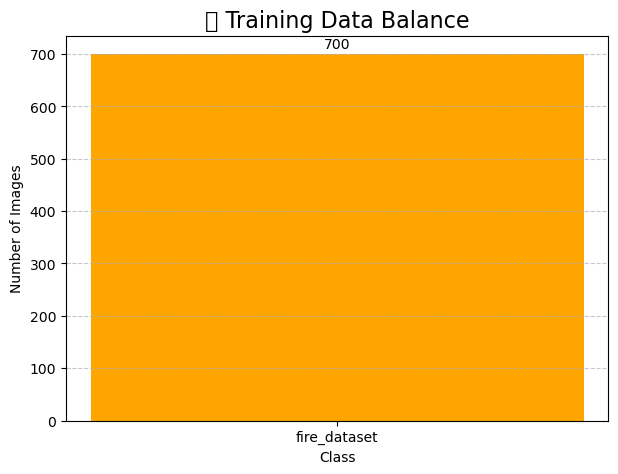

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Assuming you created the dataset like this:
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     train_dir,
#     image_size=(224, 224),
#     batch_size=32
# )

# Get class names
class_names = train_ds.class_names

# Count samples per class
count_dict = {class_name: 0 for class_name in class_names}

for _, labels in train_ds.unbatch():
    label_idx = labels.numpy()
    class_name = class_names[label_idx]
    count_dict[class_name] += 1

# Prepare data for plotting
classes = list(count_dict.keys())
counts = list(count_dict.values())

# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(classes, counts, color=['orange', 'green'])
plt.title("🔥 Training Data Balance", fontsize=16)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=10)

plt.show()


C:\Users\avikr\AppData\Local\Temp\ipykernel_2096\1829464845.py:48: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\avikr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


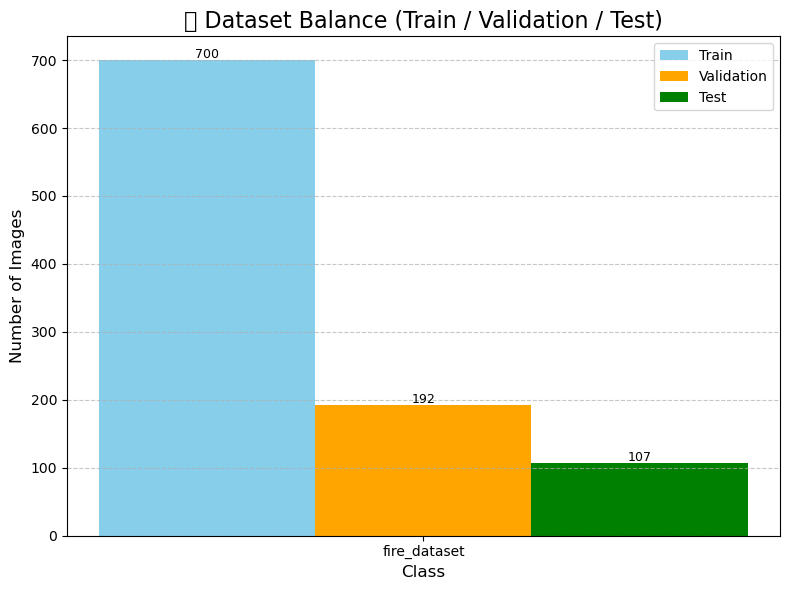

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Function to count samples per class
def count_classes(dataset, class_names):
    counts = {name: 0 for name in class_names}
    for _, label in dataset.unbatch():
        label_idx = label.numpy()
        counts[class_names[label_idx]] += 1
    return counts

# Get class names (from any split)
class_names = train_ds.class_names

# Count samples for each split
train_counts = count_classes(train_ds, class_names)
val_counts = count_classes(val_ds, class_names)
test_counts = count_classes(test_ds, class_names)

# Prepare data for plotting
x = np.arange(len(class_names))  # [0, 1, ...]
width = 0.25  # bar width

# Plot bars
plt.figure(figsize=(8, 6))
plt.bar(x - width, [train_counts[c] for c in class_names], width, label='Train', color='skyblue')
plt.bar(x, [val_counts[c] for c in class_names], width, label='Validation', color='orange')
plt.bar(x + width, [test_counts[c] for c in class_names], width, label='Test', color='green')

# Labels and aesthetics
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("🔥 Dataset Balance (Train / Validation / Test)", fontsize=16)
plt.xticks(x, class_names)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
def add_labels(bars, counts):
    for i, val in enumerate(counts):
        plt.text(bars[i], val + 3, str(val), ha='center', fontsize=9)

add_labels(x - width, [train_counts[c] for c in class_names])
add_labels(x, [val_counts[c] for c in class_names])
add_labels(x + width, [test_counts[c] for c in class_names])

plt.tight_layout()
plt.show()


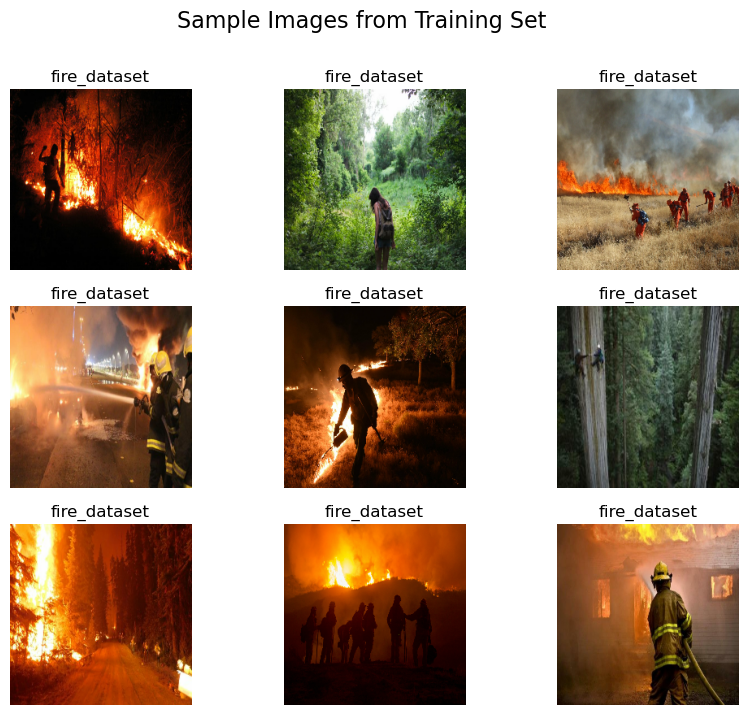

In [11]:

# -------------------------------
# 6. Visualize samples
# -------------------------------
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_name = train_ds.class_names[labels[i]]
        plt.title(label_name)
        plt.axis("off")
plt.suptitle("Sample Images from Training Set", fontsize=16)
plt.show()


In [12]:
# -------------------------------
# 7. Normalize the images (0–1)
# -------------------------------
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
# ------------------------------------------
# 3. Build CNN model
# ------------------------------------------
model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.summary()


c:\Users\avikr\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 614,929 (2.35 MB)

 Trainable params: 614,929 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:

# ------------------------------------------
# 4. Compile the model
# ------------------------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [13]:
# ------------------------------------------
# 5. Train the model
# ------------------------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)


Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 953ms/step - accuracy: 0.6785 - loss: 0.6103 - val_accuracy: 0.7448 - val_loss: 0.3211
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 938ms/step - accuracy: 0.8372 - loss: 0.3214 - val_accuracy: 0.9427 - val_loss: 0.2002
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 990ms/step - accuracy: 0.9037 - loss: 0.2605 - val_accuracy: 0.9531 - val_loss: 0.1622
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 964ms/step - accuracy: 0.9438 - loss: 0.1611 - val_accuracy: 0.9688 - val_loss: 0.1265
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 949ms/step - accuracy: 0.9414 - loss: 0.1623 - val_accuracy: 0.9740 - val_loss: 0.1158
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 963ms/step - accuracy: 0.9382 - loss: 0.1584 - val_accuracy: 0.9583 - val_loss: 0.1410
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 929ms/step - accuracy: 0.9559 - loss: 0.1228 - val_accuracy: 0.9479 - val_loss: 0.1649
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 921ms/step - accuracy: 0.9745 - loss: 0.0756 - val_accu

In [15]:
# ------------------------------------------
# 6. Evaluate on test set
# ------------------------------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.1308 - loss: 0.7051

✅ Test Accuracy: 0.1308
✅ Test Loss: 0.7051


NameError: name 'history' is not defined

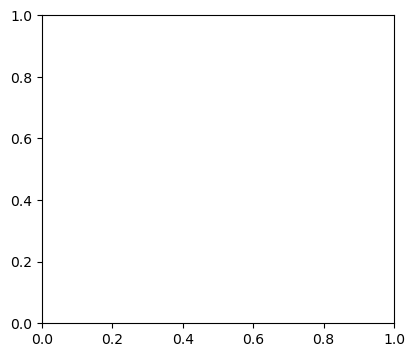

In [ ]:
# ------------------------------------------
# 7. Plot training results
# ------------------------------------------
if 'history' not in globals():
	raise NameError("history is not defined. Run the training cell (model.fit) before plotting.")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


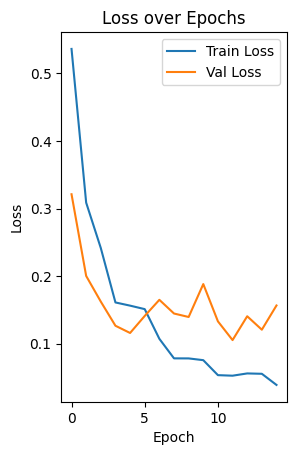

In [16]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [17]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# ------------------------------------------
# Helper: Get predictions and true labels
# ------------------------------------------
def get_predictions_and_labels(model, dataset):
    y_true = []
    y_pred = []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        preds = (preds > 0.5).astype("int32").flatten()  # Binary threshold
        y_pred.extend(preds)
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)





🧩 Training Set Metrics:
                 precision    recall  f1-score   support

    fire_images       0.99      1.00      0.99       529
non_fire_images       1.00      0.95      0.98       171

       accuracy                           0.99       700
      macro avg       0.99      0.98      0.98       700
   weighted avg       0.99      0.99      0.99       700

F1-Score: 0.9760479041916168


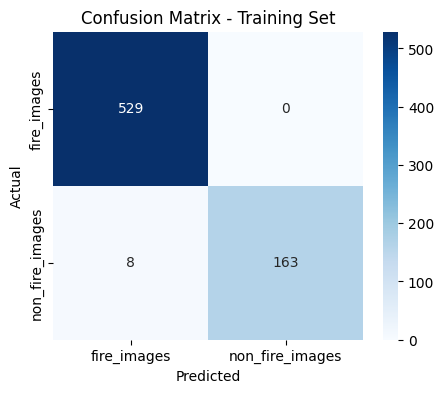

In [18]:

# ------------------------------------------
# 1. Evaluate on Train Set
# ------------------------------------------
y_train_true, y_train_pred = get_predictions_and_labels(model, train_ds)
print("\n🧩 Training Set Metrics:")
print(classification_report(y_train_true, y_train_pred, target_names=class_names))
print("F1-Score:", f1_score(y_train_true, y_train_pred))

# Confusion matrix for train
cm_train = confusion_matrix(y_train_true, y_train_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Training Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


🧩 Validation Set Metrics:
                 precision    recall  f1-score   support

    fire_images       0.97      0.99      0.98       148
non_fire_images       0.95      0.91      0.93        44

       accuracy                           0.97       192
      macro avg       0.96      0.95      0.96       192
   weighted avg       0.97      0.97      0.97       192

F1-Score: 0.9302325581395349


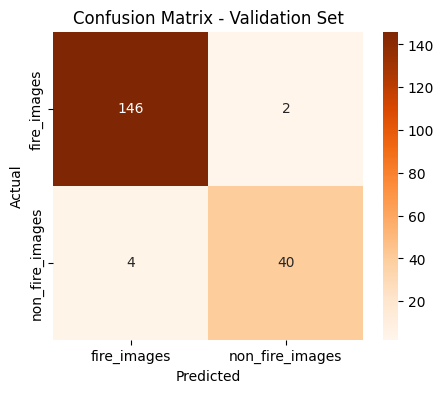

In [19]:

# ------------------------------------------
# 2. Evaluate on Validation Set
# ------------------------------------------
y_val_true, y_val_pred = get_predictions_and_labels(model, val_ds)
print("\n🧩 Validation Set Metrics:")
print(classification_report(y_val_true, y_val_pred, target_names=class_names))
print("F1-Score:", f1_score(y_val_true, y_val_pred))

cm_val = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



🧩 Test Set Metrics:
                 precision    recall  f1-score   support

    fire_images       0.96      1.00      0.98        74
non_fire_images       1.00      0.91      0.95        33

       accuracy                           0.97       107
      macro avg       0.98      0.95      0.97       107
   weighted avg       0.97      0.97      0.97       107

F1-Score: 0.9523809523809523


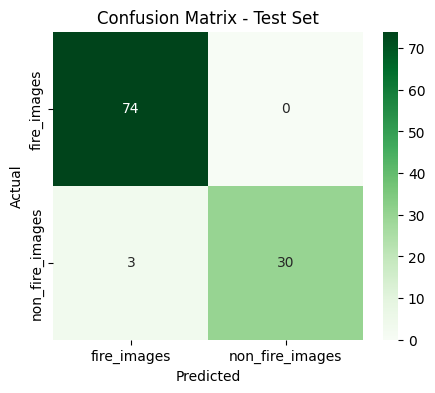

In [20]:
# ------------------------------------------
# 3. Evaluate on Test Set
# ------------------------------------------
y_test_true, y_test_pred = get_predictions_and_labels(model, test_ds)
print("\n🧩 Test Set Metrics:")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))
print("F1-Score:", f1_score(y_test_true, y_test_pred))

cm_test = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


/tmp/ipykernel_13/1039122379.py:40: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


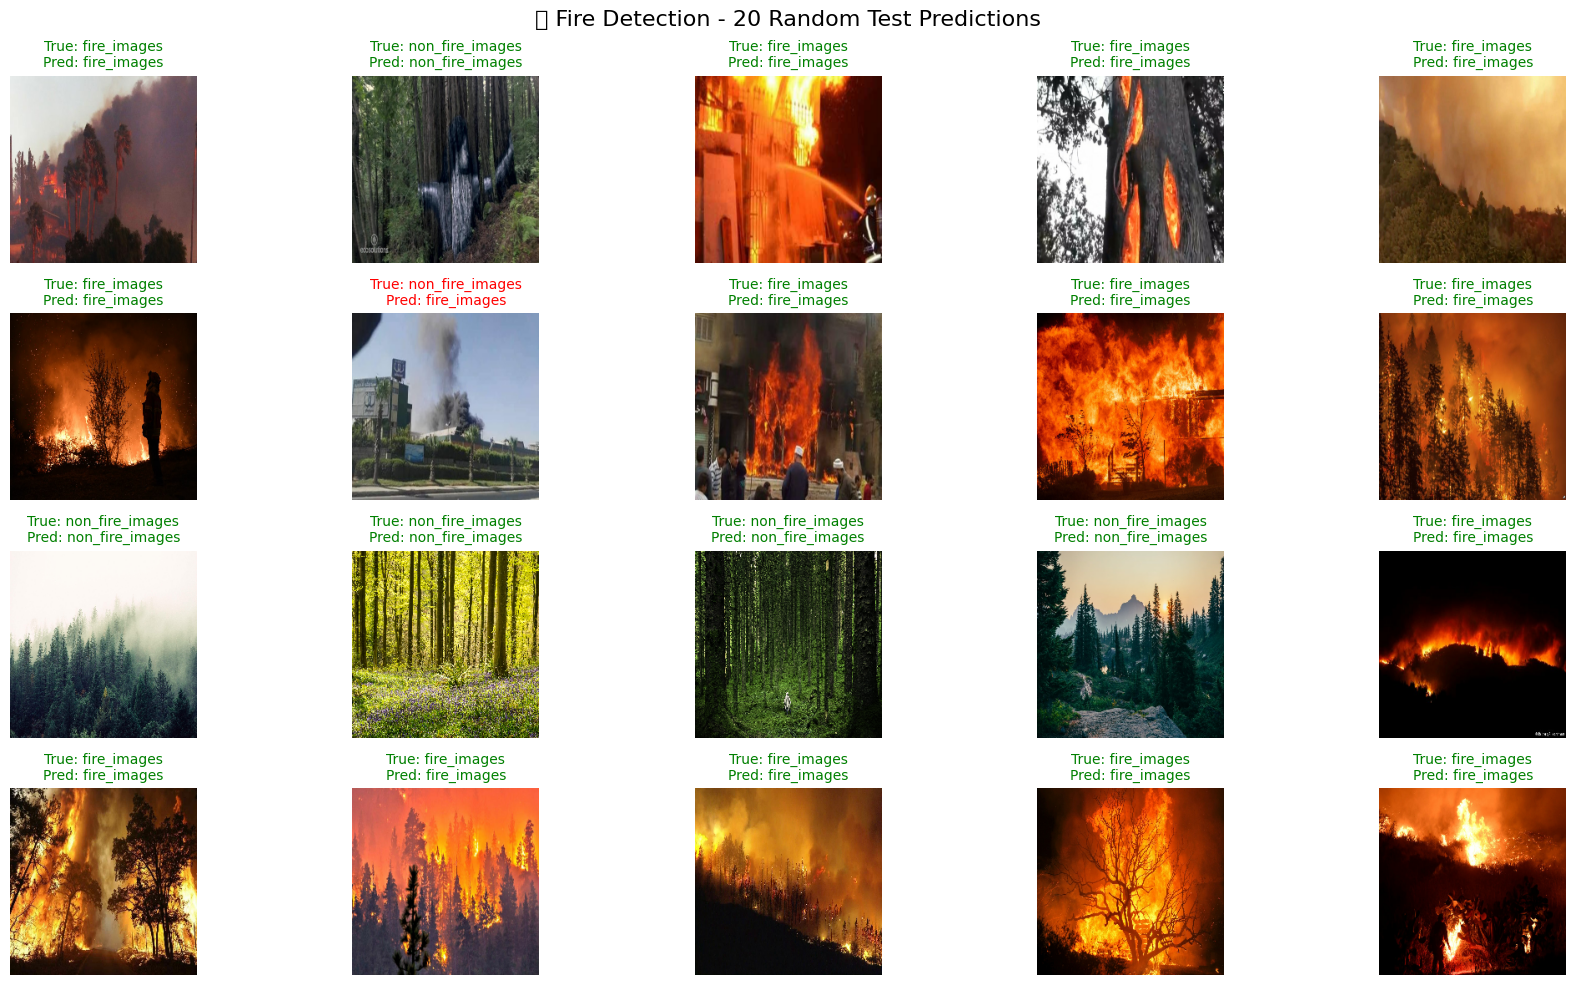

In [21]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import random

# Assume test_ds and class_names are already defined
images, labels = [], []
for img, label in test_ds.unbatch():
    images.append(img)
    labels.append(label.numpy())
images = np.array(images)
labels = np.array(labels)

random_indices = random.sample(range(len(images)), 20)

plt.figure(figsize=(18, 10))
for i, idx in enumerate(random_indices):
    img = images[idx]
    true_label = labels[idx]

    # Predict
    img_batch = tf.expand_dims(img, axis=0)
    pred = model.predict(img_batch, verbose=0)

    # Detect output type (sigmoid or softmax)
    if pred.shape[-1] == 1:   # sigmoid output
        pred_label = int(pred[0][0] > 0.5)
    else:                     # softmax output
        pred_label = np.argmax(pred, axis=1)[0]

    color = "green" if true_label == pred_label else "red"

    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
              color=color, fontsize=10)

plt.suptitle("🔥 Fire Detection - 20 Random Test Predictions", fontsize=16)
plt.tight_layout()
plt.show()


In [22]:
model.save("fire_detection_model.h5")  # or .keras


In [23]:
from tensorflow.keras.models import load_model

# Recreate the same model architecture

model.load_weights("/kaggle/working/fire_detection_model.h5")